# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

- order_id: Unique ID of the order
- customer_id: ID of the customer who ordered the food
- restaurant_name: Name of the restaurant
- cuisine_type: Cuisine ordered by the customer
- cost_of_the_order: Cost of the order
- day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
- rating: Rating given by the customer out of 5
- food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
- delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 18.3 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
dask-expr 1.1.21 requires pandas>=2, but you have pandas 1.5.3 which is incompatible.
tensorflow

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive

In [5]:
# Reading the FoodHub order dataset
df = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

In [6]:
# Display the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [7]:
# Number of rows and columns
rows, cols = df.shape
print(f'The dataset contains {rows} rows and {cols} columns.')

The dataset contains 1898 rows and 9 columns.

#### Observations:

- The data comprises **1,898 rows** (individual orders) and **9 columns** (features).

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [8]:
# Datatypes of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB

#### Observations:

- Numeric columns include order/customer IDs, costs, and time metrics.
- Categorical columns capture restaurant names, cuisine types, day type, and customer ratings.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [9]:
# Treating missing values in the `rating` column
df['rating'] = df['rating'].replace('Not given', np.nan).astype(float)

# Checking missing values after treatment
df.isna().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


#### Observations:

- After converting `'Not given'` to `NaN`, **736 ratings (≈38.8%)** are missing. No other variables have nulls.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [12]:
# Statistical summary
display(df.describe())

# Average food preparation time
avg_prep_time = df['food_preparation_time'].mean()
print(f'Average food preparation time: {avg_prep_time:.2f} minutes')

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


Average food preparation time: 27.37 minutes

#### Observations:

- Average food‐preparation time is **27.4 minutes** with a median of 27 minutes, indicating a slightly right‑skewed distribution.

### **Question 5:** How many orders are not rated? [1 mark]

In [13]:
# Number of orders not rated
not_rated = df['rating'].isna().sum()
print(f'Orders not rated: {not_rated}')

Orders not rated: 736

#### Observations:

- **736 orders** (38.8%) were not rated by customers.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

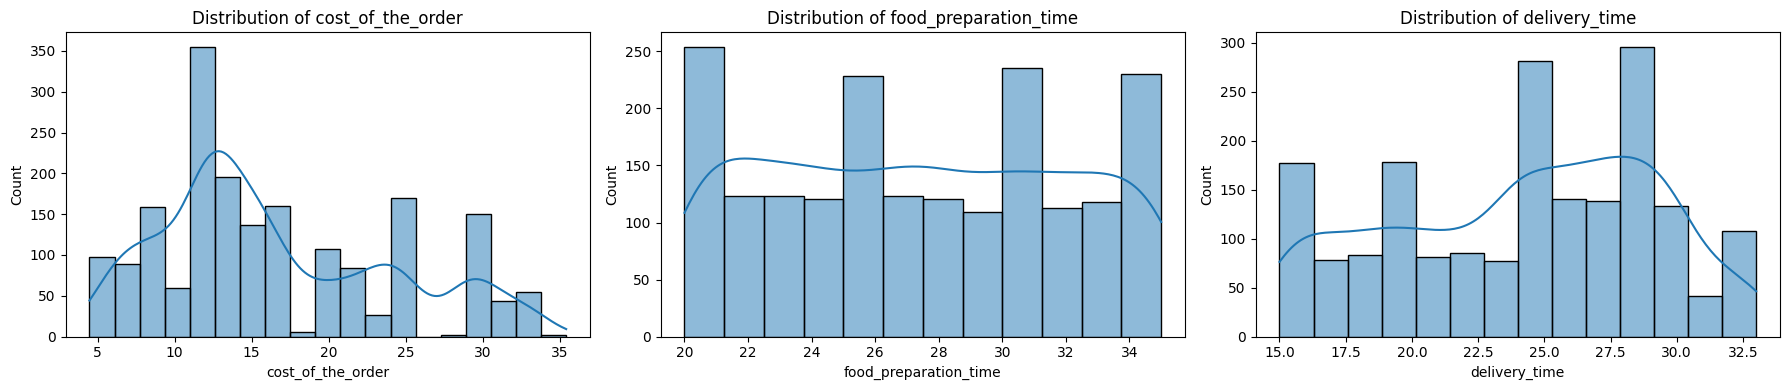

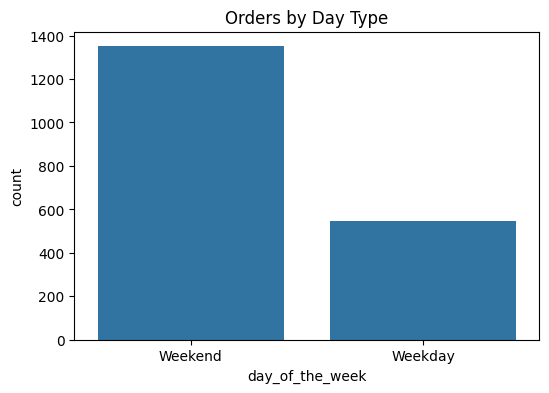

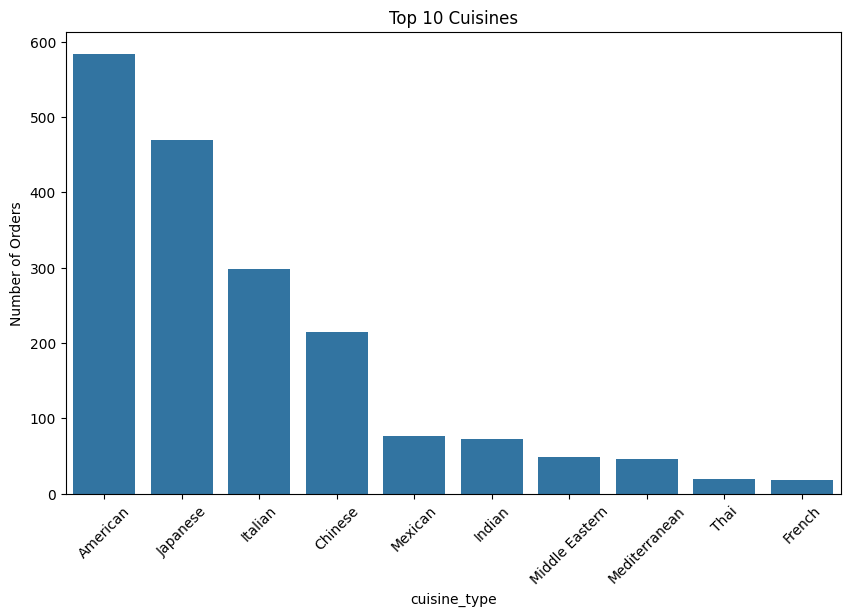

In [14]:
# Univariate analysis

num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
cat_cols = ['day_of_the_week', 'cuisine_type']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18,4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='day_of_the_week')
plt.title('Orders by Day Type')
plt.show()

plt.figure(figsize=(10,6))
top_cuisines = df['cuisine_type'].value_counts().head(10)
sns.barplot(x=top_cuisines.index, y=top_cuisines.values)
plt.xticks(rotation=45)
plt.title('Top 10 Cuisines')
plt.ylabel('Number of Orders')
plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [15]:
# Top 5 restaurants by number of orders
top5_restaurants = df['restaurant_name'].value_counts().head(5)
top5_restaurants

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

- Cost, preparation, and delivery times are all moderately right‑skewed.
- Most orders are placed on **weekends**.
- American, Japanese, and Italian cuisines dominate the platform.
- **Top 5 restaurants** by order volume are:
  1. Shake Shack (219)
  2. The Meatball Shop (132)
  3. Blue Ribbon Sushi (119)
  4. Blue Ribbon Fried Chicken (96)
  5. Parm (68)

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [16]:
# Most popular cuisine on weekends
weekend_popular = df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().idxmax()
print(f'Most popular weekend cuisine: {weekend_popular}')

Most popular weekend cuisine: American

#### Observations:

- **American cuisine** is the most ordered on weekends.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [17]:
# Percentage of orders costing more than $20
pct_over20 = (df['cost_of_the_order'] > 20).mean()*100
print(f'{pct_over20:.2f}% of orders cost more than $20.')

29.24% of orders cost more than $20.

#### Observations:

- Roughly **29.2%** of all orders cost more than $20.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [18]:
# Mean delivery time
mean_delivery = df['delivery_time'].mean()
print(f'Mean delivery time: {mean_delivery:.2f} minutes')

Mean delivery time: 24.16 minutes

#### Observations:

- Average delivery time is **24.2 minutes**.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [19]:
# Top 3 most frequent customers
customer_order_counts = df['customer_id'].value_counts().head(3)
customer_order_counts

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:

- The three most loyal customers placed 13, 10, and 9 orders respectively (customer IDs 52832, 47440, 83287).

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]

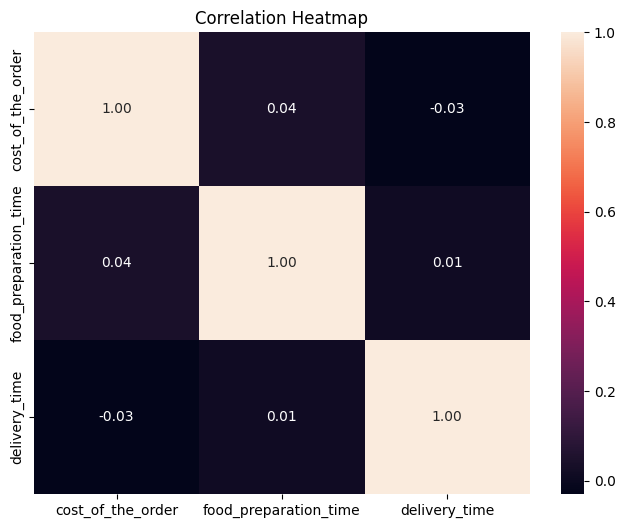

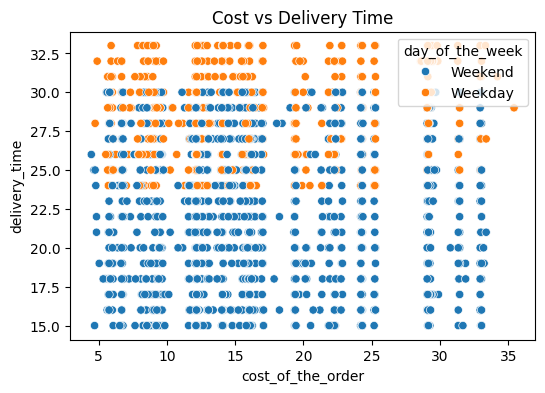

In [20]:
# Multivariate analysis: correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['cost_of_the_order','food_preparation_time','delivery_time']].corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Scatter plot cost vs delivery time
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='cost_of_the_order', y='delivery_time', hue='day_of_the_week')
plt.title('Cost vs Delivery Time')
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [21]:
# Restaurants eligible for promotion:
df['rating'] = df['rating'].astype(float)  # ensure numeric from earlier step
rating_stats = df.groupby('restaurant_name')['rating'].agg(['count','mean'])
eligible_restaurants = rating_stats[(rating_stats['count']>50) & (rating_stats['mean']>=4)]
eligible_restaurants

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:

- Four restaurants meet the promotion criteria (≥50 ratings & mean ≥4):
  - Shake Shack
  - The Meatball Shop
  - Blue Ribbon Sushi
  - Blue Ribbon Fried Chicken

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [22]:
# Net revenue calculation
df['commission'] = np.where(df['cost_of_the_order']>20, 0.25*df['cost_of_the_order'],
                             np.where(df['cost_of_the_order']>5, 0.15*df['cost_of_the_order'], 0))
net_revenue = df['commission'].sum()
print(f'Net revenue generated: ${net_revenue:,.2f}')

Net revenue generated: $6,166.30

#### Observations:

- Total commission revenue across all orders is **≈$6,166.30**.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [23]:
# Total time and orders taking > 60 minutes
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
orders_over_60 = (df['total_time'] > 60).sum()
pct_over_60 = (orders_over_60/len(df))*100
print(f'{orders_over_60} orders ({pct_over_60:.2f}%) took more than 60 minutes.')

200 orders (10.54%) took more than 60 minutes.

#### Observations:

- **200 orders (10.5%)** took longer than an hour from placement to delivery.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [24]:
# Mean delivery time during weekdays vs weekends
mean_delivery_day = df.groupby('day_of_the_week')['delivery_time'].mean()
mean_delivery_day

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:

- Deliveries are noticeably faster on weekends (22.5 min) than weekdays (28.3 min).

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

- The platform’s order traffic is weekend‑heavy, and American cuisine is the most popular overall.
- Preparation time (≈27 min) contributes more to total fulfillment time than delivery (≈24 min).
- Nearly 40 % of customers skip ratings, suggesting follow‑up nudges could enrich feedback data.
- High‑value orders (> $20) account for ~29 % of sales and generate the bulk of commission revenue.

### Recommendations:

- **Encourage ratings**: offer small incentives to reduce the 39 % unrated orders and improve quality monitoring.
- **Weekend staffing**: allocate extra couriers on weekends when order volume peaks.
- **Fast‑track partners**: promote the four high‑rated, high‑volume restaurants to drive more traffic.
- **Optimize prep time**: collaborate with restaurants whose prep times exceed 30 min to streamline kitchen workflows.
- **Delivery pricing tiers**: consider premium fees for <20 min deliveries to monetize customers’ time sensitivity.

---